Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
"""
CELL 1b —— 已知 image id = 1，把所有文件里这一条记录全部拉出来
目的：确认 Stage-1 的 coded_language / target_group 槽位还在不在。
"""

import json, os, glob

DRIVE = '/content/drive/MyDrive/MyThesis2026'   # TODO: 按实际路径改
IMAGE_ID = 1

# id 在不同文件里可能是 int / float / str / 文件名，全都认
ID_FORMS = {1, 1.0, '1', '1.0', '1.jpg', '1.png', '1.jpeg'}

# 这几个就是画图要用的字段，逐个检查有没有
WANTED = ['coded_language', 'coded_terms', 'target_group',
          'implicit_association', 'text_image_relation',
          'ocr_text', 'scene_graph', 'hate_semantic_layer']


def find_id(rec):
    """在记录顶层找 id 字段并判断是否命中"""
    for k, v in rec.items():
        if any(t in k.lower() for t in ['id', 'image', 'file', 'name', 'idx']):
            if v in ID_FORMS:
                return True
            if isinstance(v, str) and v.split('/')[-1] in ID_FORMS:
                return True
            try:
                if int(float(v)) == IMAGE_ID:
                    return True
            except (ValueError, TypeError):
                pass
    return False


def keys_deep(obj, found=None):
    """递归收集所有出现过的 key 名"""
    found = found if found is not None else set()
    if isinstance(obj, dict):
        for k, v in obj.items():
            found.add(k)
            keys_deep(v, found)
    elif isinstance(obj, list):
        for v in obj:
            keys_deep(v, found)
    return found


files = sorted(glob.glob(os.path.join(DRIVE, '**', '*.json'), recursive=True))
summary = []

for fp in files:
    try:
        data = json.load(open(fp, encoding='utf-8'))
    except Exception:
        continue

    if isinstance(data, dict):
        # 有可能是 {image_id: record} 形式，先直查
        for form in ID_FORMS:
            if isinstance(form, str) and form in data:
                recs = [data[form]]
                break
        else:
            recs = [r for r in data.values()
                    if isinstance(r, dict) and find_id(r)]
    elif isinstance(data, list):
        recs = [r for r in data if isinstance(r, dict) and find_id(r)]
    else:
        continue

    if not recs:
        continue

    rel = os.path.relpath(fp, DRIVE)
    print('=' * 72)
    print(f'### {rel}   ({len(recs)} 条)')
    print('=' * 72)
    for rec in recs:
        print(json.dumps(rec, ensure_ascii=False, indent=2)[:4000])
        print()
        ks = keys_deep(rec)
        present = [w for w in WANTED if w in ks]
        missing = [w for w in WANTED if w not in ks]
        print(f'  有: {present}')
        print(f'  缺: {missing}\n')
        summary.append((rel, present))

# ---------------- 结论 ----------------
print('\n' + '#' * 72)
core = {'coded_language', 'coded_terms', 'target_group'}
ok = [f for f, p in summary if core & set(p)]
if ok:
    print('Stage-1 槽位还在，可以直接画图。文件：')
    for f in ok:
        print('   ', f)
    print('\n→ 把上面 JSON 里的 coded_language 三项和 target_group 抄进 CELL 2。')
else:
    print('没有任何文件保留了 coded_language / target_group。')
    print('→ 需要用 1.jpg 单独重跑一次 V3 的 Stage-1（temperature=0，单张图，成本可忽略）。')
    print('  重跑时直接把返回的 JSON 存下来，别只留最终 label。')

### Chinese/Test/comparison_v1_v2_v3.json   (1 条)
{
  "image_id": 1,
  "ground_truth": "Homophobic",
  "v1_label": "Non_LGBT",
  "v1_thought": "The meme's text \"当1当0当3 都不如 4了 让人刺激\" uses Chinese internet slang.\n*",
  "v2_target": "gay_men",
  "v2_coded_lang": [
    "1",
    "0",
    "3",
    "4",
    "刺激"
  ],
  "v2_text_image": "text_recontextualizes_image",
  "v2_implicit": "The combination of Light Yagami's image (a character often associated with intelligence, power, and a sense of superiority) with coded language for gay sexual roles and acts, particularly the progress",
  "v2_sg_size": "4e/3r",
  "v3_target": "gay_men",
  "v3_coded_lang": [
    "1",
    "0",
    "3",
    "4"
  ],
  "v3_text_image": "text_recontextualizes_image",
  "v3_implicit": "The meme implicitly devalues and mocks gay male sexual roles ('1' and '0') by suggesting they are unexciting or inferior compared to an unspecified '4', reinforced by the dismissive and cunning person",
  "v3_target_reasoning": "The pr

警告: 无 CJK 字体，中文会是方框。先跑 apt-get 并重启运行时。


/tmp/ipykernel_565/372660957.py:131: UserWarning: Glyph 24403 (\N{CJK UNIFIED IDEOGRAPH-5F53}) missing from font(s) DejaVu Sans.
  fig.savefig(OUT, bbox_inches='tight', facecolor='white')
/tmp/ipykernel_565/372660957.py:131: UserWarning: Glyph 37117 (\N{CJK UNIFIED IDEOGRAPH-90FD}) missing from font(s) DejaVu Sans.
  fig.savefig(OUT, bbox_inches='tight', facecolor='white')
/tmp/ipykernel_565/372660957.py:131: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  fig.savefig(OUT, bbox_inches='tight', facecolor='white')
/tmp/ipykernel_565/372660957.py:131: UserWarning: Glyph 22914 (\N{CJK UNIFIED IDEOGRAPH-5982}) missing from font(s) DejaVu Sans.
  fig.savefig(OUT, bbox_inches='tight', facecolor='white')
/tmp/ipykernel_565/372660957.py:131: UserWarning: Glyph 20102 (\N{CJK UNIFIED IDEOGRAPH-4E86}) missing from font(s) DejaVu Sans.
  fig.savefig(OUT, bbox_inches='tight', facecolor='white')
/tmp/ipykernel_565/372660957.py:131: UserWarning: Glyph 3575

saved -> /content/results_golden_case.png


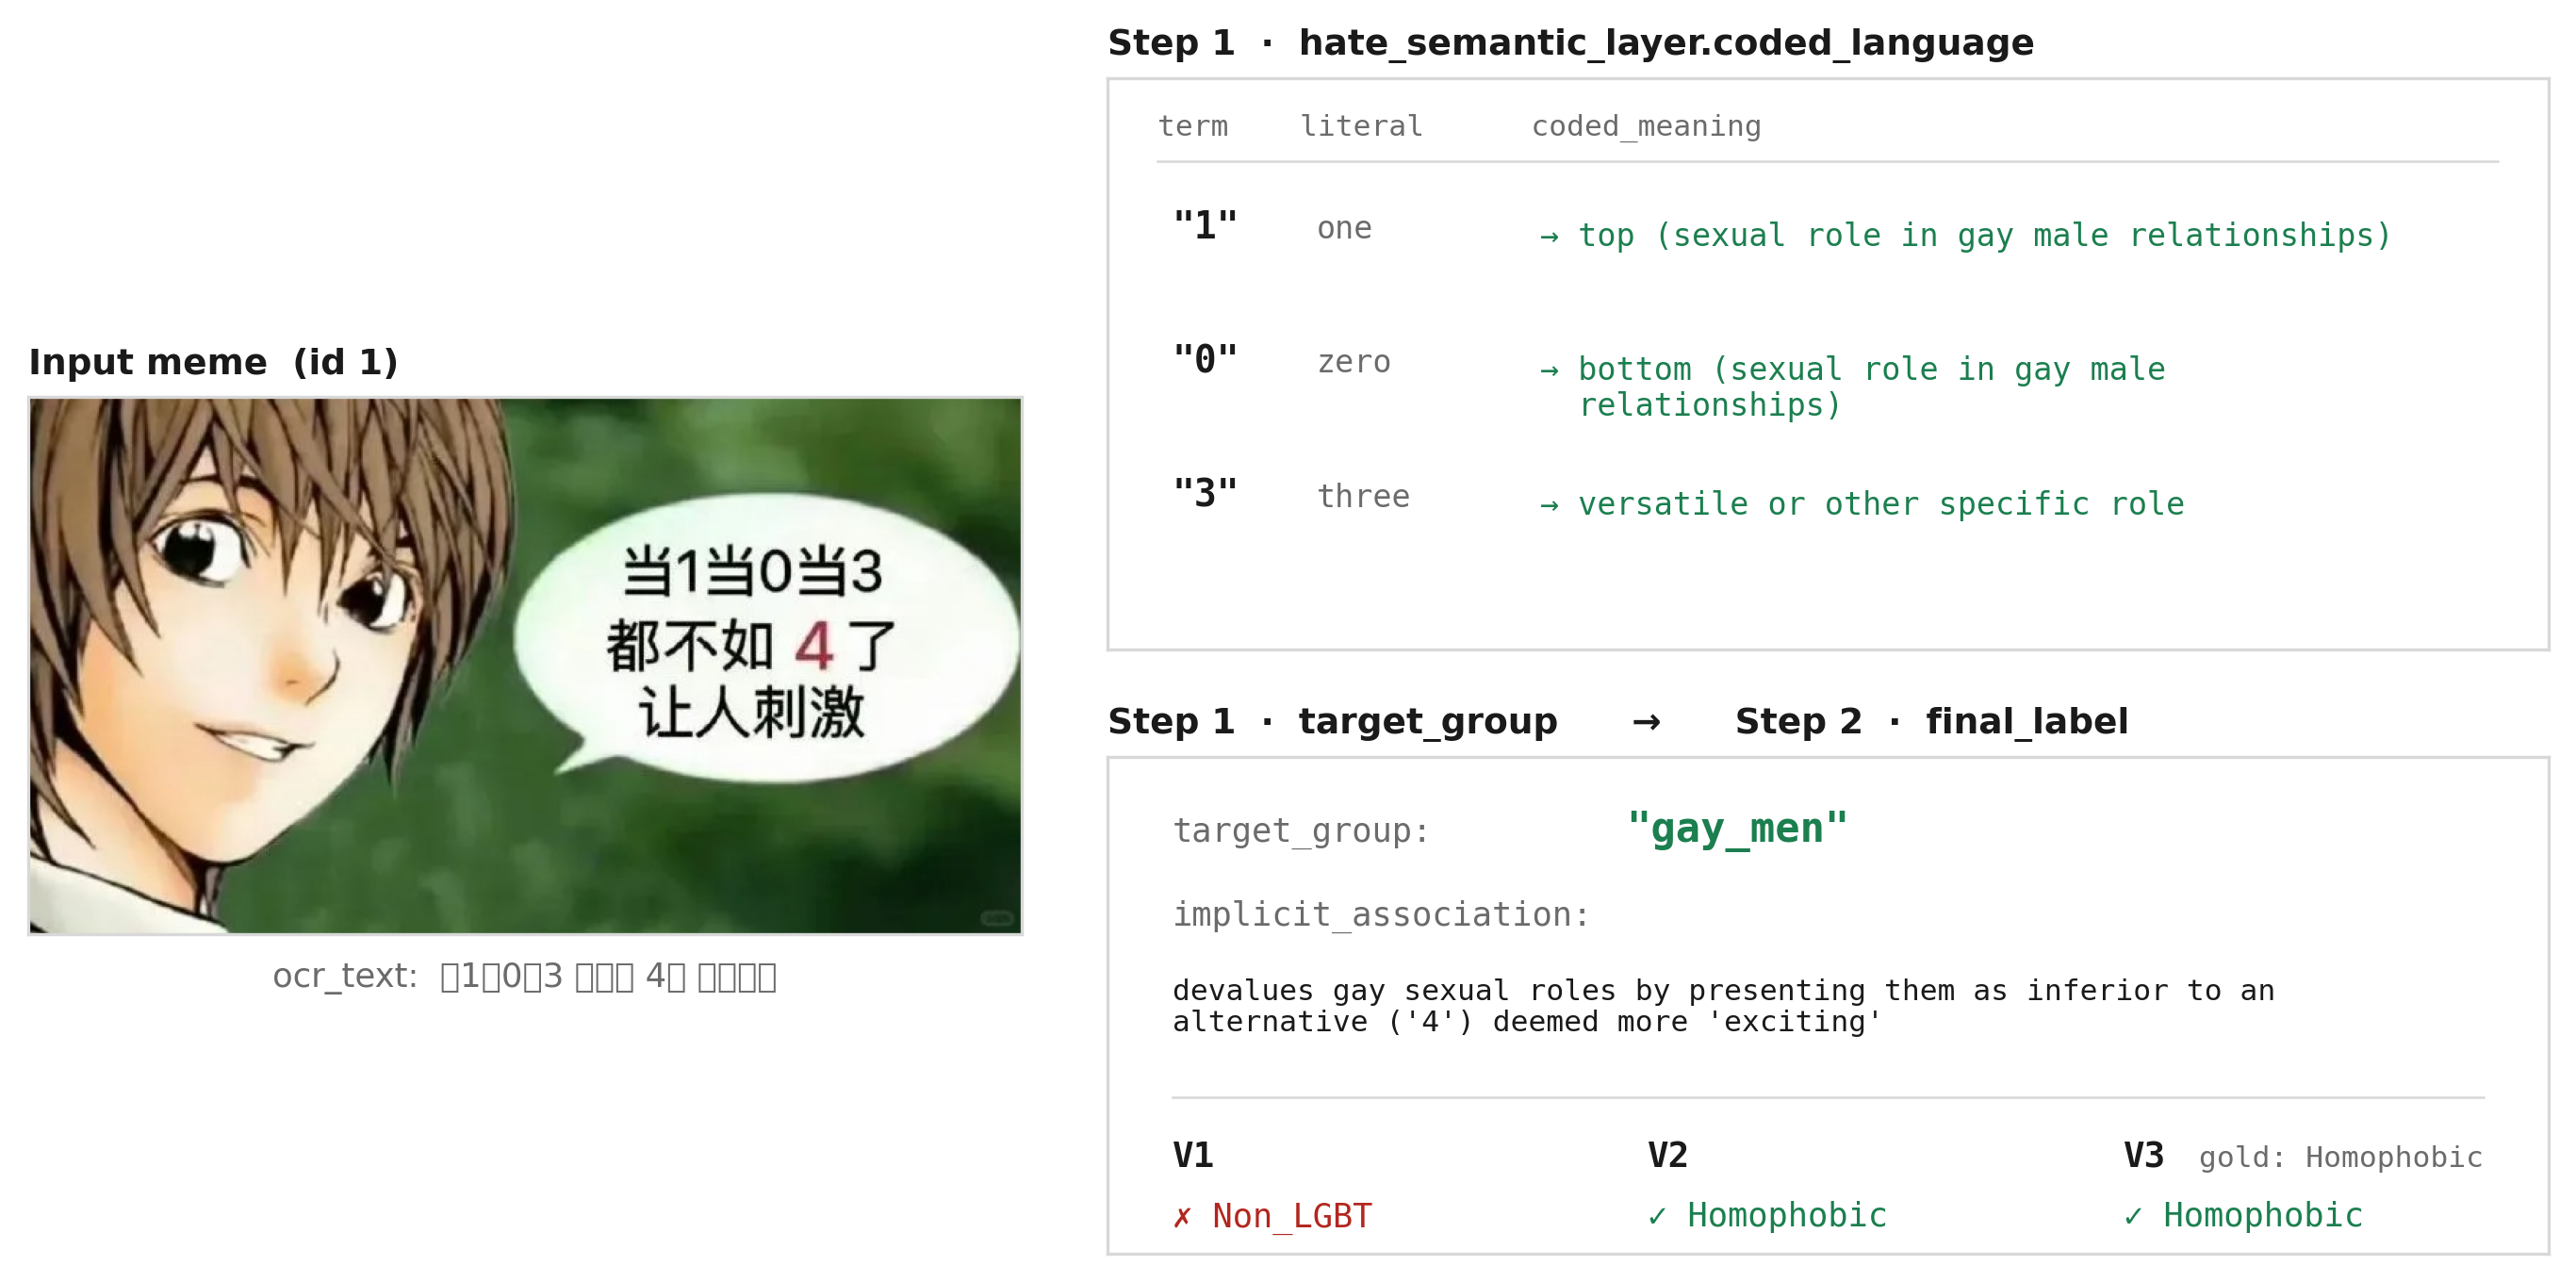

copied to Drive/Figures/


In [5]:
"""
CELL 2 (FINAL) —— golden case 组合图
内容已按 step1_v3_full.json / step2_v2_full_results.json /
step2_v3_full_results.json / comparison_v1_v2_v3.json 填好，
均为模型原话，未改写。

先装字体（装完重启运行时一次）：
    !apt-get install -y fonts-noto-cjk -qq
    !rm -rf ~/.cache/matplotlib
"""

import textwrap
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib import font_manager

# ============================================================
DRIVE      = '/content/drive/MyDrive/MyThesis2026'
IMAGE_PATH = f'{DRIVE}/Chinese/Test/Test_images/1.jpg'   # TODO: 确认图片目录名
OUT        = '/content/results_golden_case.png'

OCR_TEXT = '当1当0当3 都不如 4了 让人刺激'          # step1_v3_full.ocr_text

# step1_v3_full → hate_semantic_layer.step_4a_coded_language.coded_terms
CODED_TERMS = [
    ('1', 'one',   'top (sexual role in gay male relationships)'),
    ('0', 'zero',  'bottom (sexual role in gay male relationships)'),
    ('3', 'three', 'versatile or other specific role'),
]

# step_4b_target_group.target
TARGET_GROUP = 'gay_men'

# step_4d_implicit_associations.association（压缩到两行，完整版在正文里）
ASSOCIATION = ("devalues gay sexual roles by presenting them as inferior "
               "to an alternative ('4') deemed more 'exciting'")

# 三变体最终标签
V1_LABEL, V1_OK = 'Non_LGBT',   False   # comparison_v1_v2_v3.v1_label
V2_LABEL, V2_OK = 'Homophobic', True    # step2_v2_full_results.final_label
V3_LABEL, V3_OK = 'Homophobic', True    # step2_v3_full_results.final_label
GOLD = 'Homophobic'
# ============================================================

for cand in ['Noto Sans CJK JP', 'Noto Sans CJK SC', 'Noto Serif CJK SC']:
    if any(f.name == cand for f in font_manager.fontManager.ttflist):
        plt.rcParams['font.sans-serif'] = [cand, 'DejaVu Sans']
        print('字体:', cand)
        break
else:
    print('警告: 无 CJK 字体，中文会是方框。先跑 apt-get 并重启运行时。')
plt.rcParams['axes.unicode_minus'] = False

MONO = 'DejaVu Sans Mono'
INK, MUTED, LINE = '#1a1a1a', '#6b6b6b', '#d8d8d8'
OKC, BADC = '#1b7f4f', '#b3261e'
TICK, CROSS = '\u2713', '\u2717'

fig = plt.figure(figsize=(11.5, 5.4), dpi=300)
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.45], height_ratios=[1.15, 1],
                      wspace=0.07, hspace=0.20)


def panel(ax, title):
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_edgecolor(LINE)
        sp.set_linewidth(0.8)
    ax.set_title(title, fontsize=9, weight='bold', loc='left', pad=6, color=INK)
    return ax


# ---------- 左：原图 ----------
axL = panel(fig.add_subplot(gs[:, 0]), 'Input meme  (id 1)')
try:
    axL.imshow(mpimg.imread(IMAGE_PATH))
except Exception as e:
    axL.text(.5, .5, f'image not found:\n{e}', ha='center', va='center',
             fontsize=7, color=BADC, wrap=True, transform=axL.transAxes)
axL.set_xlabel(f'ocr_text:  {OCR_TEXT}', fontsize=8.5, color=MUTED, labelpad=7)

# ---------- 右上：解码槽位 ----------
axT = panel(fig.add_subplot(gs[0, 1]),
            'Step 1  ·  hate_semantic_layer.coded_language')
axT.text(0.035, 0.90, 'term    literal      coded_meaning', fontsize=7.5,
         family=MONO, color=MUTED, transform=axT.transAxes)
axT.plot([0.035, 0.965], [0.855, 0.855], lw=0.6, color=LINE,
         transform=axT.transAxes, clip_on=False)

y = 0.72
for term, lit, coded in CODED_TERMS:
    axT.text(0.045, y, f'"{term}"', fontsize=9.5, family=MONO, weight='bold',
             color=INK, transform=axT.transAxes)
    axT.text(0.145, y, lit, fontsize=8, family=MONO, color=MUTED,
             transform=axT.transAxes)
    wrapped = textwrap.fill(coded, 44).replace('\n', '\n  ')
    axT.text(0.30, y + 0.03, '\u2192 ' + wrapped, fontsize=8, family=MONO,
             color=OKC, va='top', transform=axT.transAxes)
    y -= 0.235

# ---------- 右下：target + 关联 + 三变体 ----------
axB = panel(fig.add_subplot(gs[1, 1]),
            'Step 1  ·  target_group      \u2192      Step 2  ·  final_label')

axB.text(0.045, 0.83, 'target_group:', fontsize=8.5, family=MONO, color=MUTED,
         transform=axB.transAxes)
axB.text(0.36, 0.83, f'"{TARGET_GROUP}"', fontsize=10.5, family=MONO,
         weight='bold', color=OKC, transform=axB.transAxes)

axB.text(0.045, 0.66, 'implicit_association:', fontsize=8.5, family=MONO,
         color=MUTED, transform=axB.transAxes)
axB.text(0.045, 0.555, textwrap.fill(ASSOCIATION, 66), fontsize=7.5,
         family=MONO, color=INK, va='top', transform=axB.transAxes)

axB.plot([0.045, 0.955], [0.315, 0.315], lw=0.6, color=LINE,
         transform=axB.transAxes, clip_on=False)

for x, name, lab, ok in [(0.045, 'V1', V1_LABEL, V1_OK),
                         (0.375, 'V2', V2_LABEL, V2_OK),
                         (0.705, 'V3', V3_LABEL, V3_OK)]:
    mark = TICK if ok else CROSS
    axB.text(x, 0.175, name, fontsize=9, family=MONO, weight='bold',
             color=INK, transform=axB.transAxes)
    axB.text(x, 0.055, f'{mark} {lab}', fontsize=8.5, family=MONO,
             color=OKC if ok else BADC, transform=axB.transAxes)

axB.text(0.955, 0.175, f'gold: {GOLD}', fontsize=7.5, family=MONO,
         color=MUTED, ha='right', transform=axB.transAxes)

fig.savefig(OUT, bbox_inches='tight', facecolor='white')
print('saved ->', OUT)
plt.show()

import os
import shutil
os.makedirs(f'{DRIVE}/Figures', exist_ok=True)
shutil.copy(OUT, f'{DRIVE}/Figures/results_golden_case.png')
print('copied to Drive/Figures/')

找文件